In [12]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import pandas as pd
import warnings

import time
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, brier_score_loss

warnings.filterwarnings('ignore')
pyro.set_rng_seed(179)
pyro.clear_param_store()
pd.set_option('display.max_columns', None)

# Load data

In [2]:
games = pd.read_csv("matchups.csv")
team_logs = pd.read_csv("team_logs.csv")

required_cols = ["HOME_TEAM_ID", "AWAY_TEAM_ID", "HOME_WIN", "SEASON"]
missing_cols = [col for col in required_cols if col not in games.columns]
if missing_cols:
    raise ValueError(f"matchups.csv is missing required columns: {missing_cols}")

games = games.dropna(subset=required_cols).reset_index(drop=True)
games["HOME_WIN"] = games["HOME_WIN"].astype(int)
games["HOME_TEAM_ID"] = games["HOME_TEAM_ID"].astype(int)
games["AWAY_TEAM_ID"] = games["AWAY_TEAM_ID"].astype(int)

home_names = games[["HOME_TEAM_ID", "HOME_TEAM_NAME"]].rename(columns={"HOME_TEAM_ID": "TEAM_ID", "HOME_TEAM_NAME": "TEAM_NAME"})
away_names = games[["AWAY_TEAM_ID", "AWAY_TEAM_NAME"]].rename(columns={"AWAY_TEAM_ID": "TEAM_ID", "AWAY_TEAM_NAME": "TEAM_NAME"})
team_names = pd.concat([home_names, away_names, team_logs[["TEAM_ID", "TEAM_NAME"]]], ignore_index=True).dropna()
team_name_map = team_names.drop_duplicates("TEAM_ID").set_index("TEAM_ID")["TEAM_NAME"].to_dict()
season_label = ", ".join(map(str, sorted(games["SEASON"].unique())))

print(f"Games loaded: {len(games)}")
print(f"Seasons covered: {season_label}")
print(f"Home win rate: {games['HOME_WIN'].mean():.3f}")
display(games.head())

Games loaded: 3642
Seasons covered: 2021-22, 2022-23, 2023-24
Home win rate: 0.556


,GAME_ID,HOME_TEAM_ID,HOME_TEAM_NAME,HOME_WIN,SEASON,HOME_ROLL10_PTS,HOME_ROLL10_FGA,HOME_ROLL10_FG_PCT,HOME_ROLL10_FG3_PCT,HOME_ROLL10_FT_PCT,HOME_ROLL10_REB,HOME_ROLL10_AST,HOME_ROLL10_TOV,HOME_ROLL10_STL,HOME_ROLL10_BLK,AWAY_TEAM_ID,AWAY_TEAM_NAME,AWAY_WIN,AWAY_ROLL10_PTS,AWAY_ROLL10_FGA,AWAY_ROLL10_FG_PCT,AWAY_ROLL10_FG3_PCT,AWAY_ROLL10_FT_PCT,AWAY_ROLL10_REB,AWAY_ROLL10_AST,AWAY_ROLL10_TOV,AWAY_ROLL10_STL,AWAY_ROLL10_BLK,DIFF_ROLL10_PTS,DIFF_ROLL10_FGA,DIFF_ROLL10_FG_PCT,DIFF_ROLL10_FG3_PCT,DIFF_ROLL10_FT_PCT,DIFF_ROLL10_REB,DIFF_ROLL10_AST,DIFF_ROLL10_TOV,DIFF_ROLL10_STL,DIFF_ROLL10_BLK
0,22100097,1610612737,Atlanta Hawks,1,2021-22,106.166667,93.666667,0.452500,0.335833,0.758333,50.833333,24.333333,13.000,6.333333,3.833333,1610612764,Washington Wizards,0,112.666667,92.833333,0.442333,0.322667,0.8075,50.333333,20.500000,12.666667,7.333333,6.166667,-6.500000,0.833333,0.010167,0.013167,-0.049167,0.500000,3.833333,0.333333,-1.000000,-2.333333
1,22100120,1610612737,Atlanta Hawks,0,2021-22,107.875000,92.375000,0.451125,0.346000,0.802125,50.500000,24.125000,12.875,6.875000,4.000000,1610612762,Utah Jazz,1,112.285714,88.000000,0.448143,0.320000,0.8390,51.428571,17.428571,14.857143,7.285714,5.857143,-4.410714,4.375000,0.002982,0.026000,-0.036875,-0.928571,6.696429,-1.982143,-0.410714,-1.857143
2,22100193,1610612737,Atlanta Hawks,1,2021-22,105.500000,89.500000,0.440200,0.340200,0.783200,44.500000,21.700000,12.600,5.900000,3.400000,1610612749,Milwaukee Bucks,0,106.700000,90.800000,0.435500,0.352200,0.7401,46.000000,21.900000,12.400000,7.800000,4.300000,-1.200000,-1.300000,0.004700,-0.012000,0.043100,-1.500000,-0.200000,0.200000,-1.900000,-0.900000
3,22100202,1610612737,Atlanta Hawks,1,2021-22,107.300000,89.600000,0.447000,0.356400,0.785400,44.100000,21.700000,12.700,6.100000,3.100000,1610612753,Orlando Magic,0,98.500000,86.900000,0.418000,0.333700,0.7457,43.600000,21.100000,15.900000,6.600000,5.500000,8.800000,2.700000,0.029000,0.022700,0.039700,0.500000,0.600000,-3.200000,-0.500000,-2.400000
4,22100215,1610612737,Atlanta Hawks,1,2021-22,109.100000,89.300000,0.447800,0.374500,0.786700,44.400000,22.300000,12.500,6.700000,3.500000,1610612738,Boston Celtics,0,103.700000,87.700000,0.440900,0.307100,0.7929,45.100000,20.700000,13.500000,7.600000,5.200000,5.400000,1.600000,0.006900,0.067400,-0.006200,-0.700000,1.600000,-1.000000,-0.900000,-1.700000


# Prepare Model Inputs

In [3]:
# map NBA team IDs to 0..N-1 indices for the strength vector
all_team_ids = sorted(set(games["HOME_TEAM_ID"]) | set(games["AWAY_TEAM_ID"]))

team_id_to_idx = {tid: i for i, tid in enumerate(all_team_ids)}
idx_to_team_id = {i: tid for tid, i in team_id_to_idx.items()}
idx_to_team    = {i: team_name_map.get(tid, str(tid)) for i, tid in idx_to_team_id.items()}
team_to_idx    = {name: i for i, name in idx_to_team.items()}

home_idx = torch.tensor([team_id_to_idx[t] for t in games["HOME_TEAM_ID"]], dtype=torch.long)
away_idx = torch.tensor([team_id_to_idx[t] for t in games["AWAY_TEAM_ID"]], dtype=torch.long)
outcomes = torch.tensor(games["HOME_WIN"].values, dtype=torch.float) 

num_teams = len(all_team_ids)
num_games  = len(games)
home_win_rate = outcomes.mean().item()

print(f"Number of teams: {num_teams}")
print(f"Number of games: {num_games}")
print(f"Home win rate:   {home_win_rate:.3f}")

Number of teams: 30
Number of games: 3642
Home win rate:   0.556


# Define the Probabilistic Model

In [4]:
#Bayesian latent strength model
#strengths[i] ~ Normal(0,1) per team, home_adv ~ Normal(0,1) global
#outcome ~ Bernoulli(sigmoid(strength_home - strength_away + home_adv))

def model(home_idx, away_idx, outcomes=None):
    num_teams = int(torch.max(torch.cat([home_idx, away_idx])).item()) + 1

    strengths = pyro.sample(
        'strengths',
        dist.Normal(torch.zeros(num_teams), torch.ones(num_teams)).to_event(1)
    )

    home_adv = pyro.sample('home_adv', dist.Normal(torch.tensor(0.), torch.tensor(1.)))

    logits = strengths[home_idx] - strengths[away_idx] + home_adv

    with pyro.plate('games', len(home_idx)):
        pyro.sample('obs', dist.Bernoulli(logits=logits), obs=outcomes)

# Run NUTS Inference

In [13]:
start_time = time.time()

nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=500, warmup_steps=200, num_chains=1)
mcmc.run(home_idx, away_idx, outcomes)

end_time = time.time()

runtime_seconds = end_time - start_time
samples = mcmc.get_samples()

print(f"MCMC runtime: {runtime_seconds:.2f} seconds")

Sample: 100%|██████████| 700/700 [00:17, 40.85it/s, step size=3.54e-01, acc. prob=0.883]

MCMC runtime: 17.14 seconds


# Posterior Team Strength Rankings

In [6]:
#posterior mean and std per team from the 500 NUTS samples
strength_samples = samples['strengths'].detach().cpu()
posterior_mean = strength_samples.mean(dim=0).numpy()
posterior_std  = strength_samples.std(dim=0).numpy()

rankings = pd.DataFrame({
    'team_name':     [idx_to_team[idx] for idx in range(num_teams)],
    'mean_strength': posterior_mean,
    'std_strength':  posterior_std,
}).sort_values('mean_strength', ascending=False).reset_index(drop=True)

print('Top 10 teams by posterior mean strength:')
display(rankings.head(10))

print('Bottom 5 teams by posterior mean strength:')
display(rankings.tail(5))

Top 10 teams by posterior mean strength:


,team_name,mean_strength,std_strength
0,Boston Celtics,0.759826,0.231897
1,Phoenix Suns,0.510491,0.223092
2,Denver Nuggets,0.498284,0.220815
3,Milwaukee Bucks,0.482068,0.229482
4,Philadelphia 76ers,0.373382,0.223748
5,Minnesota Timberwolves,0.259794,0.227244
6,Golden State Warriors,0.227202,0.223997
7,Cleveland Cavaliers,0.220515,0.222553
8,Miami Heat,0.211774,0.222474
9,Dallas Mavericks,0.179706,0.226217


Bottom 5 teams by posterior mean strength:


,team_name,mean_strength,std_strength
25,Houston Rockets,-0.760877,0.224072
26,Washington Wizards,-0.776655,0.221466
27,Portland Trail Blazers,-0.804579,0.237493
28,San Antonio Spurs,-0.863705,0.226590
29,Detroit Pistons,-1.348897,0.238759


# Visualize Team Strength Rankings

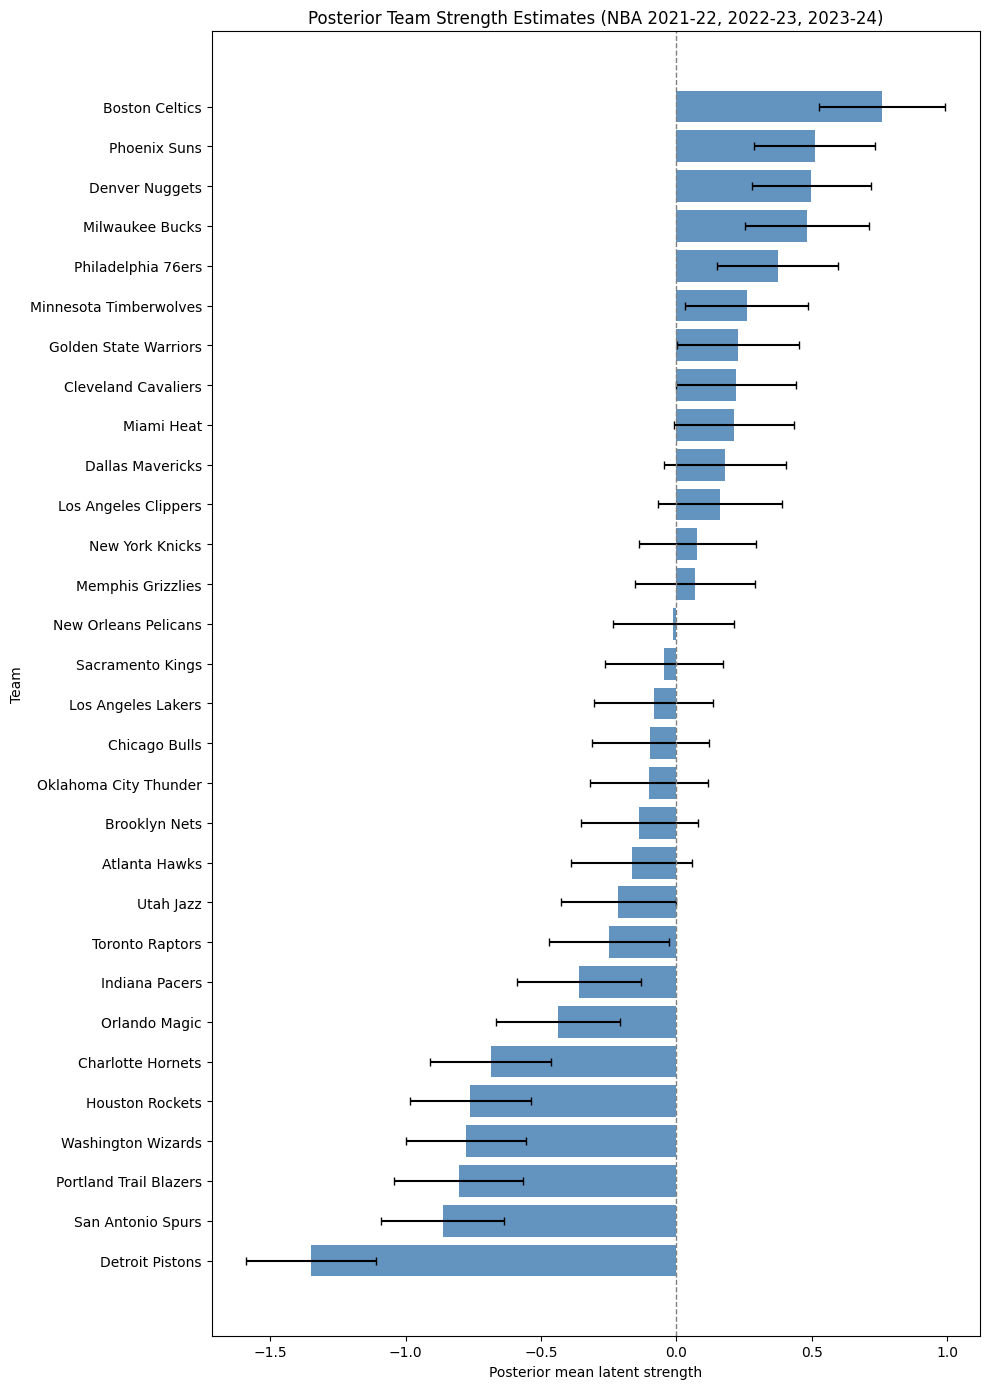

In [7]:
# Horizontal bar chart of all teams ranked by posterior mean strength. Error bars = +/- 1 posterior std
plot_df = rankings.sort_values('mean_strength', ascending=True)

plt.figure(figsize=(10, 14))
plt.barh(
    plot_df['team_name'],
    plot_df['mean_strength'],
    xerr=plot_df['std_strength'],
    color='steelblue',
    alpha=0.85,
    ecolor='black',
    capsize=3,
)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title(f'Posterior Team Strength Estimates (NBA {season_label})')
plt.xlabel('Posterior mean latent strength')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('team_strengths.png', dpi=200, bbox_inches='tight')
plt.show()

# Home Court Advantage Posterior

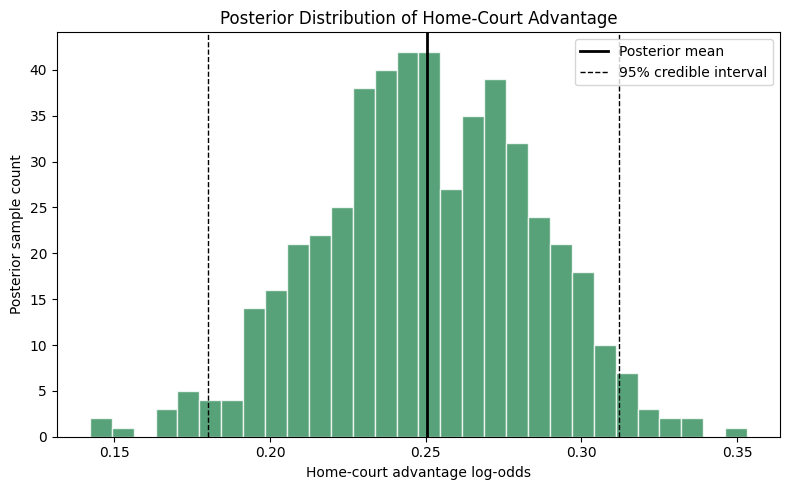

Posterior mean home-court advantage: 0.250
95% credible interval: [0.180, 0.312]


In [8]:
# posterior over home_adv with mean and 95% credible interval
home_adv_samples = samples['home_adv'].detach().cpu().numpy()
home_adv_mean = home_adv_samples.mean()
home_adv_ci   = np.percentile(home_adv_samples, [2.5, 97.5])

plt.figure(figsize=(8, 5))
plt.hist(home_adv_samples, bins=30, color='seagreen', alpha=0.8, edgecolor='white')
plt.axvline(home_adv_mean,   color='black', linestyle='-',  linewidth=2, label='Posterior mean')
plt.axvline(home_adv_ci[0],  color='black', linestyle='--', linewidth=1, label='95% credible interval')
plt.axvline(home_adv_ci[1],  color='black', linestyle='--', linewidth=1)
plt.title('Posterior Distribution of Home-Court Advantage')
plt.xlabel('Home-court advantage log-odds')
plt.ylabel('Posterior sample count')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Posterior mean home-court advantage: {home_adv_mean:.3f}')
print(f'95% credible interval: [{home_adv_ci[0]:.3f}, {home_adv_ci[1]:.3f}]')

# Uncertainty vs. Data Size Analysis

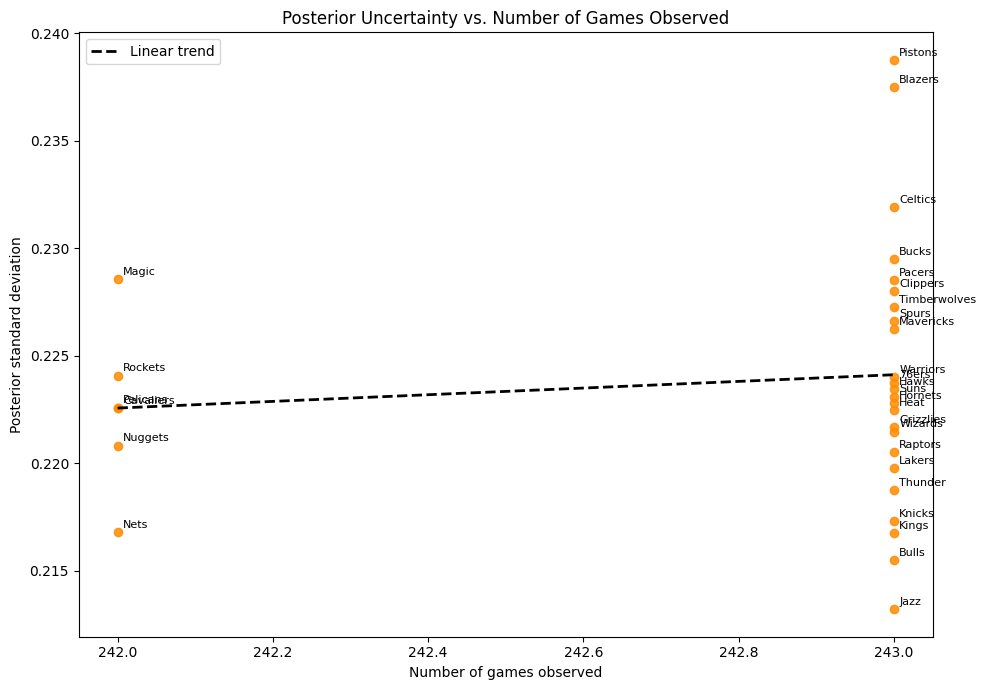

In [9]:
# compare posterior uncertainty to games observed, more data should mean narrower posteriors

home_counts  = games.groupby("HOME_TEAM_ID").size()
away_counts  = games.groupby("AWAY_TEAM_ID").size()
games_by_team = home_counts.add(away_counts, fill_value=0)

label_by_team_id = {tid: name.split()[-1] for tid, name in team_name_map.items()}

uncertainty_df = pd.DataFrame({
    'team_id':      [idx_to_team_id[idx] for idx in range(num_teams)],
    'team_name':    [idx_to_team[idx] for idx in range(num_teams)],
    'n_games':      [games_by_team.loc[idx_to_team_id[idx]] for idx in range(num_teams)],
    'posterior_std': posterior_std,
})
uncertainty_df['label'] = uncertainty_df['team_id'].map(label_by_team_id)

x = uncertainty_df['n_games'].to_numpy(dtype=float)
y = uncertainty_df['posterior_std'].to_numpy(dtype=float)

# trend line
slope, intercept = np.polyfit(x, y, deg=1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(10, 7))
plt.scatter(x, y, color='darkorange', alpha=0.85)
plt.plot(x_line, y_line, color='black', linestyle='--', linewidth=2, label='Linear trend')

for _, row in uncertainty_df.iterrows():
    plt.annotate(row['label'], (row['n_games'], row['posterior_std']),
                 fontsize=8, xytext=(4, 3), textcoords='offset points')

plt.title('Posterior Uncertainty vs. Number of Games Observed')
plt.xlabel('Number of games observed')
plt.ylabel('Posterior standard deviation')
plt.legend()
plt.tight_layout()
plt.show()

#  Posterior Predictive Probability

In [26]:
def predict_proba(home_team_name, away_team_name, samples, team_to_idx, idx_to_name=None):
    """
    Returns the posterior predictive probability that the home team wins.

    home_team_name : str  full team name
    away_team_name : str  full team name
    samples        : dict from mcmc.get_samples()
    team_to_idx    : dict mapping team name to integer index

    Returns: float in [0, 1], probability the home team wins
    """
    if home_team_name not in team_to_idx:
        raise KeyError(f'Unknown home team name: {home_team_name}')
    if away_team_name not in team_to_idx:
        raise KeyError(f'Unknown away team name: {away_team_name}')

    h = team_to_idx[home_team_name]
    a = team_to_idx[away_team_name]

    strength_samples  = samples['strengths']
    home_adv_samples  = samples['home_adv']

    if not torch.is_tensor(strength_samples):
        strength_samples = torch.as_tensor(strength_samples)
    if not torch.is_tensor(home_adv_samples):
        home_adv_samples = torch.as_tensor(home_adv_samples)

    logits = strength_samples[:, h] - strength_samples[:, a] + home_adv_samples
    probs  = torch.sigmoid(logits)
    return probs.mean().item()

# Predictive Accuracy Evaluation

In [ ]:
#evaluates how accurate the prediction of the model are

strength_samples = samples["strengths"].detach().cpu()
home_adv_samples = samples["home_adv"].detach().cpu()

logits_samples = (
    strength_samples[:, home_idx]
    - strength_samples[:, away_idx]
    + home_adv_samples[:, None]
)

prob_samples = torch.sigmoid(logits_samples)

y_prob = prob_samples.mean(dim=0).numpy()
y_pred = (y_prob >= 0.5).astype(int)
y_true = outcomes.detach().cpu().numpy().astype(int)

model_accuracy = accuracy_score(y_true, y_pred)
model_log_loss = log_loss(y_true, y_prob)
model_brier = brier_score_loss(y_true, y_prob)

baseline_pred = np.ones_like(y_true)
baseline_accuracy = accuracy_score(y_true, baseline_pred)

print(f"Model Accuracy: {model_accuracy:.3f}")
print(f"Baseline Accuracy: {baseline_accuracy:.3f}")
print(f"Log Loss: {model_log_loss:.3f}")
print(f"Brier Score: {model_brier:.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Model Accuracy: 0.634
Baseline Accuracy: 0.556
Log Loss: 0.635
Brier Score: 0.222
Confusion Matrix:
[[ 803  814]
 [ 518 1507]]


# Model Calibration

,probability_bin,avg_predicted_prob,actual_home_win_rate,games
0,"(0.1, 0.2]",0.167370,0.045455,22
1,"(0.2, 0.3]",0.257920,0.297143,175
2,"(0.3, 0.4]",0.354133,0.343066,411
3,"(0.4, 0.5]",0.453953,0.454418,713
4,"(0.5, 0.6]",0.551600,0.540767,834
5,"(0.6, 0.7]",0.648500,0.651192,797
6,"(0.7, 0.8]",0.743961,0.765286,507
7,"(0.8, 0.9]",0.834176,0.813559,177
8,"(0.9, 1.0]",0.912097,0.833333,6


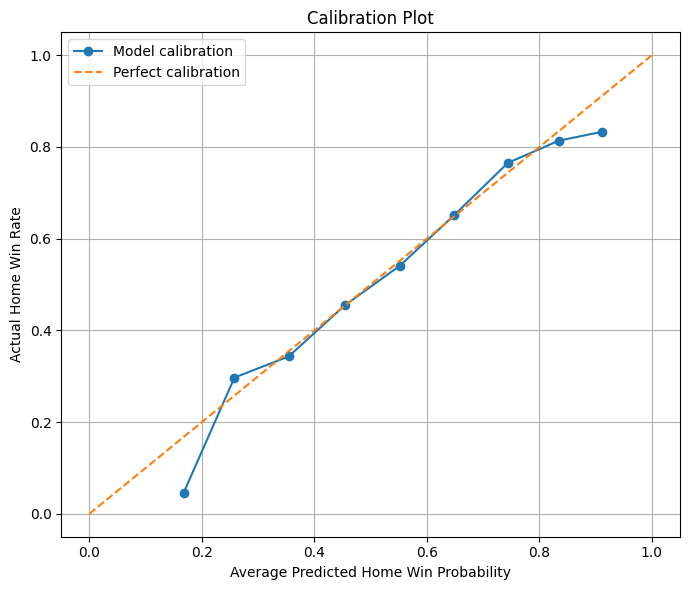

In [ ]:
#checks if the  predicted probabilities match the actual win rates

calibration_df = pd.DataFrame({
    "actual_home_win": y_true,
    "predicted_home_win_prob": y_prob
})

calibration_df["probability_bin"] = pd.cut(
    calibration_df["predicted_home_win_prob"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

calibration_summary = calibration_df.groupby("probability_bin").agg(
    avg_predicted_prob=("predicted_home_win_prob", "mean"),
    actual_home_win_rate=("actual_home_win", "mean"),
    games=("actual_home_win", "count")
).reset_index()

display(calibration_summary)

plt.figure(figsize=(7, 6))

plt.plot(
    calibration_summary["avg_predicted_prob"],
    calibration_summary["actual_home_win_rate"],
    marker="o",
    label="Model calibration"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Average Predicted Home Win Probability")
plt.ylabel("Actual Home Win Rate")
plt.title("Calibration Plot")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Setting up Train/Test Split

In [ ]:
#80% of the data is used for training, 20% for testing

split_idx = int(len(home_idx) * 0.8)

train_home_idx = home_idx[:split_idx]
train_away_idx = away_idx[:split_idx]
train_outcomes = outcomes[:split_idx]

test_home_idx = home_idx[split_idx:]
test_away_idx = away_idx[split_idx:]
test_outcomes = outcomes[split_idx:]

print("Training games:", len(train_home_idx))
print("Testing games:", len(test_home_idx))

Training games: 2913
Testing games: 729


# Evaluating Over Various Training Data Sizes

In [ ]:
#performance is checked over training data ratios of 25%, 50%, 75%, and 100%

data_size_results = []

training_fractions = [0.25, 0.50, 0.75, 1.00]

for frac in training_fractions:

    print(f"\nTraining with {int(frac * 100)}% of training data")

    num_train_games = int(len(train_home_idx) * frac)

    sub_train_home = train_home_idx[:num_train_games]
    sub_train_away = train_away_idx[:num_train_games]
    sub_train_outcomes = train_outcomes[:num_train_games]

    start_time = time.time()

    sub_kernel = NUTS(model)

    sub_mcmc = MCMC(sub_kernel, num_samples=300, warmup_steps=100, num_chains=1)

    sub_mcmc.run(sub_train_home, sub_train_away, sub_train_outcomes)

    runtime = time.time() - start_time

    sub_samples = sub_mcmc.get_samples()

    strength_samples = sub_samples["strengths"].detach().cpu()
    home_adv_samples = sub_samples["home_adv"].detach().cpu()

    logits_samples = (strength_samples[:, test_home_idx] - strength_samples[:, test_away_idx] + home_adv_samples[:, None])

    prob_samples = torch.sigmoid(logits_samples)

    y_prob = prob_samples.mean(dim=0).numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    y_true = test_outcomes.detach().cpu().numpy().astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    logloss = log_loss(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    data_size_results.append({
        "training_fraction": frac,
        "num_training_games": num_train_games,
        "accuracy": accuracy,
        "log_loss": logloss,
        "brier_score": brier,
        "runtime_seconds": runtime
    })

data_size_results = pd.DataFrame(data_size_results)

display(data_size_results)


Training with 25% of training data


Sample: 100%|██████████| 400/400 [00:08, 48.40it/s, step size=3.93e-01, acc. prob=0.857]



Training with 50% of training data


Sample: 100%|██████████| 400/400 [00:06, 59.69it/s, step size=4.62e-01, acc. prob=0.854]



Training with 75% of training data


Sample: 100%|██████████| 400/400 [00:07, 51.15it/s, step size=4.36e-01, acc. prob=0.845]



Training with 100% of training data


Sample: 100%|██████████| 400/400 [00:07, 54.88it/s, step size=4.62e-01, acc. prob=0.844]


,training_fraction,num_training_games,accuracy,log_loss,brier_score,runtime_seconds
0,0.25,728,0.551440,0.706249,0.254456,8.267550
1,0.50,1456,0.585734,0.667506,0.237434,6.704737
2,0.75,2184,0.581619,0.666346,0.237206,7.822664
3,1.00,2913,0.592593,0.664892,0.236583,7.291076


# Accuracy vs Training Data Size

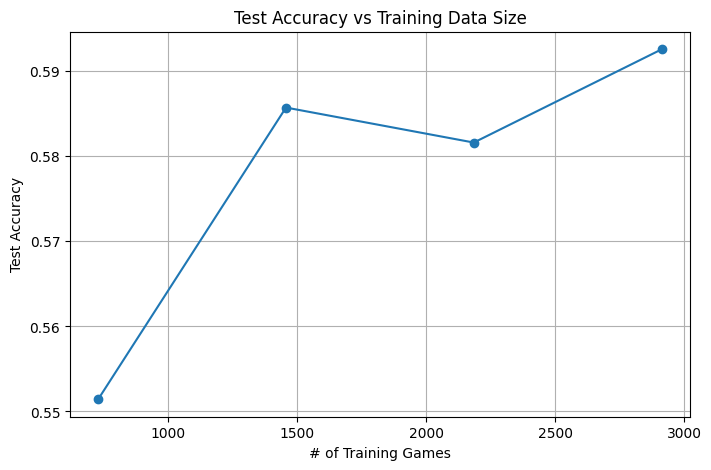

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    data_size_results["num_training_games"],
    data_size_results["accuracy"],
    marker="o"
)

plt.xlabel("# of Training Games")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Training Data Size")

plt.grid(True)
plt.show()

# Brier Score vs Training Data Size

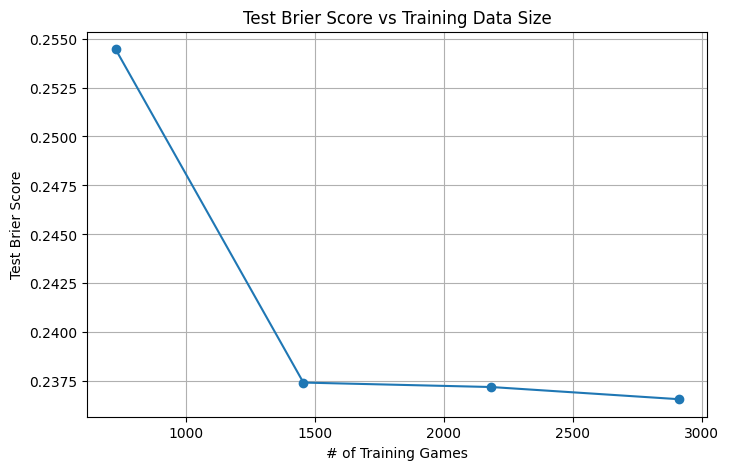

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    data_size_results["num_training_games"],
    data_size_results["brier_score"],
    marker="o"
)

plt.xlabel("# of Training Games")
plt.ylabel("Test Brier Score")
plt.title("Test Brier Score vs Training Data Size")

plt.grid(True)
plt.show()